In [1]:
import pandas as pd
import numpy as np

# ----------------------------------
# 1. Load dataset
# ----------------------------------
df = pd.read_csv("smmh.csv")

In [2]:
# ----------------------------------
# 2. Encode TIME SPENT (text)
# ----------------------------------
def encode_time(text):
    text = str(text).lower()
    if "less" in text:
        return 0.2
    if "between 1 and 2" in text:
        return 0.4
    if "between 2 and 3" in text:
        return 0.6
    if "between 3 and 4" in text:
        return 0.8
    if "more than 4" in text:
        return 1.0
    return np.nan

df_encoded = pd.DataFrame()

df_encoded["f1_time_spent"] = df[
    "8. What is the average time you spend on social media every day?"
].apply(encode_time)

In [3]:
# ----------------------------------
# 3. Normalize numeric Likert columns
# ----------------------------------
def norm_1_5(col):
    return (pd.to_numeric(col, errors="coerce") - 1) / 4

df_encoded["f2_distraction"] = norm_1_5(
    df["10. How often do you get distracted by Social media when you are busy doing something?"]
)

df_encoded["f3_restlessness"] = norm_1_5(
    df["11. Do you feel restless if you haven't used Social media in a while?"]
)

df_encoded["f4_anxiety"] = norm_1_5(
    df["13. On a scale of 1 to 5, how much are you bothered by worries?"]
)

df_encoded["f5_sleep_irregularity"] = norm_1_5(
    df["20. On a scale of 1 to 5, how often do you face issues regarding sleep?"]
)

In [4]:
# ----------------------------------
# 4. Check & clean
# ----------------------------------
print("Missing values per column:")
print(df_encoded.isna().mean())

df_encoded = df_encoded.dropna().reset_index(drop=True)
print("Rows after cleaning:", len(df_encoded))

Missing values per column:
f1_time_spent            0.380457
f2_distraction           0.000000
f3_restlessness          0.000000
f4_anxiety               0.000000
f5_sleep_irregularity    0.000000
dtype: float64
Rows after cleaning: 298


In [5]:








# ----------------------------------
# 5. Temporal variation (RL-ready)
# ----------------------------------
temporal = []
days = 5
np.random.seed(42)

for uid, row in df_encoded.iterrows():
    base = row.values
    pattern = np.random.choice(
        ["stable", "deteriorate", "recover", "volatile"],
        p=[0.4, 0.3, 0.2, 0.1]
    )

    for day in range(1, days + 1):
        noise = np.random.normal(0, 0.03, 5)

        if pattern == "deteriorate":
            drift = 0.03 * day
        elif pattern == "recover":
            drift = -0.025 * day
        elif pattern == "volatile":
            drift = np.random.uniform(-0.05, 0.06)
        else:
            drift = 0.0

        values = np.clip(base + drift + noise, 0, 1)
        temporal.append([f"U{uid:04d}", day, *values])

temporal_df = pd.DataFrame(
    temporal,
    columns=[
        "uid", "day",
        "f1_time_spent", "f2_distraction",
        "f3_restlessness", "f4_anxiety",
        "f5_sleep_irregularity"
    ]
)

print("Final temporal dataset shape:", temporal_df.shape)
print(temporal_df.head())


Final temporal dataset shape: (1490, 7)
     uid  day  f1_time_spent  f2_distraction  f3_restlessness  f4_anxiety  \
0  U0000    1       0.566644        0.509567         0.258371    0.280315   
1  U0000    2       0.584245        0.482859         0.222278    0.171624   
2  U0000    3       0.624493        0.454284         0.237159    0.227728   
3  U0000    4       0.535811        0.481116         0.267932    0.326785   
4  U0000    5       0.603667        0.484537         0.231992    0.278423   

   f5_sleep_irregularity  
0               0.982574  
1               1.000000  
2               0.978900  
3               1.000000  
4               1.000000  


In [6]:
temporal_df.to_csv("temporal_smmh_rl.csv", index=False)
print("CSV file saved as temporal_smmh_rl.csv")


CSV file saved as temporal_smmh_rl.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("temporal_smmh_rl.csv")

# Composite risk score (simple & defensible)
df["risk_score"] = df[
    ["f1_time_spent", "f2_distraction", "f3_restlessness",
     "f4_anxiety", "f5_sleep_irregularity"]
].mean(axis=1)

# Map risk to action levels (for analysis only)
def risk_to_action(r):
    if r < 0.3:
        return 0   # Good
    elif r < 0.5:
        return 1   # Moderate
    elif r < 0.7:
        return 2   # Worsening
    else:
        return 3   # Severe

df["action"] = df["risk_score"].apply(risk_to_action)


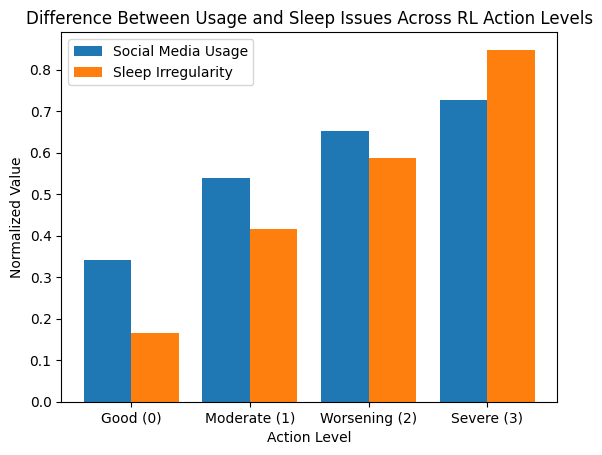

In [11]:
# Compute mean usage & sleep per action
action_means = df.groupby("action")[["f1_time_spent", "f5_sleep_irregularity"]].mean()

# Plot
plt.figure()
x = range(len(action_means))

plt.bar(x, action_means["f1_time_spent"], width=0.4, label="Social Media Usage")
plt.bar(
    [i + 0.4 for i in x],
    action_means["f5_sleep_irregularity"],
    width=0.4,
    label="Sleep Irregularity"
)

plt.xticks(
    [i + 0.2 for i in x],
    ["Good (0)", "Moderate (1)", "Worsening (2)", "Severe (3)"]
)

plt.xlabel("Action Level")
plt.ylabel("Normalized Value")
plt.title("Difference Between Usage and Sleep Issues Across RL Action Levels")
plt.legend()
plt.show()


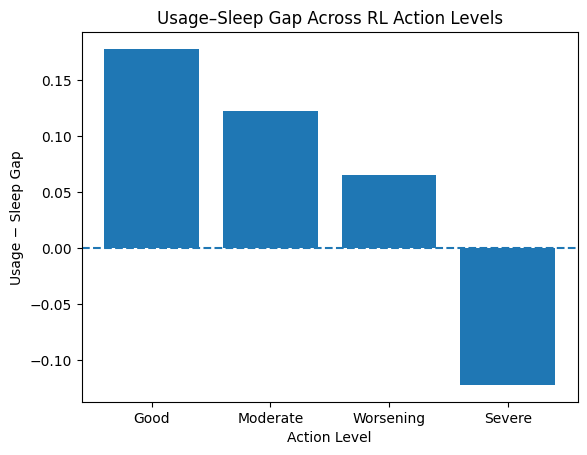

In [12]:
df["usage_sleep_gap"] = df["f1_time_spent"] - df["f5_sleep_irregularity"]

gap_means = df.groupby("action")["usage_sleep_gap"].mean()

plt.figure()
plt.bar(
    ["Good", "Moderate", "Worsening", "Severe"],
    gap_means
)

plt.axhline(0, linestyle="--")
plt.xlabel("Action Level")
plt.ylabel("Usage − Sleep Gap")
plt.title("Usage–Sleep Gap Across RL Action Levels")
plt.show()
